In [1]:
#import useful python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#load lightcurve file from SNAD
df = pd.read_parquet("snad_lightcurves_grouped_r_band.parquet")

In [3]:
df

,objectId,finkclass,oid,mjd_r,mag_r,magerr_r,filter_r
0,ZTF17aaaadkj,CataclyV*,743102100005228,"[58216.13022, 58218.20371, 58219.16895, 58219....","[17.412457, 17.338797, 17.176018, 17.167013, 1...","[0.019831764, 0.019199144, 0.017942382, 0.0178...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
1,ZTF17aaaagyq,CataclyV*,743111100012626,"[58216.13019, 58218.20368, 58219.16893, 58219....","[16.7305, 17.1317, 17.023548, 16.959763, 17.07...","[0.014744257, 0.017051972, 0.016347088, 0.0159...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2,ZTF17aaaaqna,Unknown,776105200010442,"[58278.47674, 58281.47627, 58283.46774, 58287....","[14.294525, 14.2611685, 14.537104, 14.611805, ...","[0.012580482, 0.012576667, 0.012624708, 0.0126...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
3,ZTF17aaaarmr,CataclyV*,703106200000801,"[58217.15044, 58219.1697, 58219.18939, 58231.1...","[16.110184, 16.18475, 16.07745, 16.234774, 16....","[0.015174726, 0.015401674, 0.015081054, 0.0155...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
4,ZTF17aaaazob,CataclyV*,651109400004459,"[58283.46681, 58289.47003, 58297.42487, 58300....","[17.644127, 17.994934, 17.403929, 18.084965, 1...","[0.023059644, 0.02872228, 0.02016197, 0.030504...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
...,...,...,...,...,...,...,...
2090,ZTF26aaajqnu,CataclyV*,314101100011723,"[58218.19763, 58218.22603, 58226.1396, 58226.1...","[16.501411, 16.82343, 16.635225, 16.65099, 16....","[0.014929691, 0.017087083, 0.01573768, 0.01584...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2091,ZTF26aaaombw,Unknown,413103100004106,"[58218.18849, 58218.19991, 58223.14537, 58223....","[15.509172, 15.524018, 15.55056, 15.526928, 15...","[0.010882512, 0.010905461, 0.010947581, 0.0109...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2092,ZTF26aabsgfq,Unknown,481103400002571,"[58198.4209, 58216.38505, 58216.41105, 58218.4...","[13.994027, 13.9896345, 13.987596, 13.996452, ...","[0.0107431095, 0.010741732, 0.010741096, 0.010...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2093,ZTF26aaewgqp,Unknown,487108200006414,"[58216.50843, 58217.48555, 58217.50679, 58218....","[14.528611, 14.573394, 14.575156, 14.5598955, ...","[0.016475614, 0.016494438, 0.01649521, 0.01648...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."


In [4]:
#points per sample
df['n_points'] = df['mjd_r'].apply(len)

In [5]:
df['n_points']

0        855
1        830
2       1843
3        871
4       2194
        ... 
2090     382
2091     725
2092     700
2093     934
2094     990
Name: n_points, Length: 2095, dtype: int64

In [6]:
#print class
print("Classes:", df['finkclass'].unique())


Classes: ['CataclyV*' 'Unknown' 'CataclyV*_Candidate']


In [7]:
#points per lightcurve for plotting histogram
cv_data = df[df['finkclass'].isin(['CataclyV*', 'CataclyV*_Candidate'])]['n_points']
unk_data = df[df['finkclass'] == 'Unknown']['n_points']

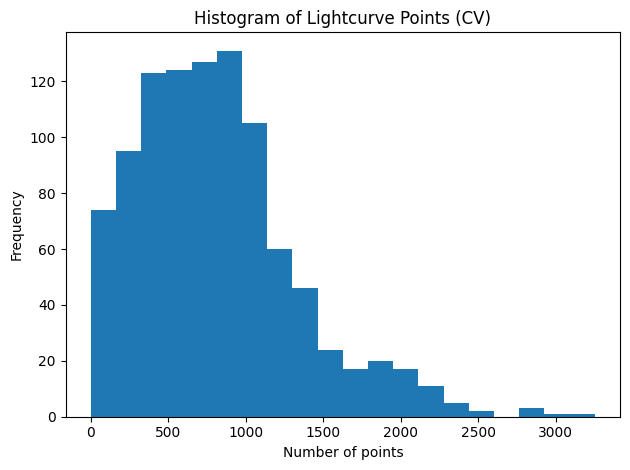

In [8]:
#plot figure
plt.figure()
plt.hist(cv_data, bins=20)

plt.xlabel("Number of points")
plt.ylabel("Frequency")
plt.title("Histogram of Lightcurve Points (CV)")
plt.tight_layout()
plt.savefig("Hist_cv.png")
plt.show()

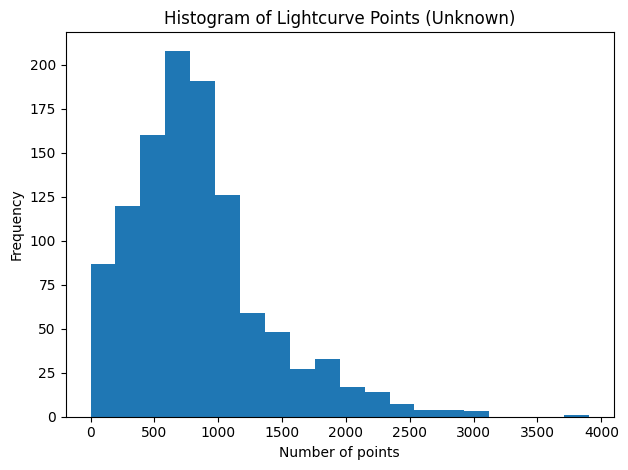

In [9]:
#plot
plt.figure()
plt.hist(unk_data, bins=20)

plt.xlabel("Number of points")
plt.ylabel("Frequency")
plt.title("Histogram of Lightcurve Points (Unknown)")
plt.tight_layout()
plt.savefig("hist_un.png")
plt.show()

In [10]:
#random object picking for light curve
cv_obj = df[df['finkclass'] == 'CataclyV*'].sample(n=1, random_state=42).iloc[0]
unk_obj = df[df['finkclass'] == 'Unknown'].sample(n=1, random_state=42).iloc[0]

In [11]:
print("CV object:", cv_obj['objectId'])
print("Unknown object:", unk_obj['objectId'])

CV object: ZTF18admdrpn
Unknown object: ZTF20aceklog


In [12]:
# CV
t_cv = np.array(cv_obj['mjd_r'])
mag_cv = np.array(cv_obj['mag_r'])
err_cv = np.array(cv_obj['magerr_r'])


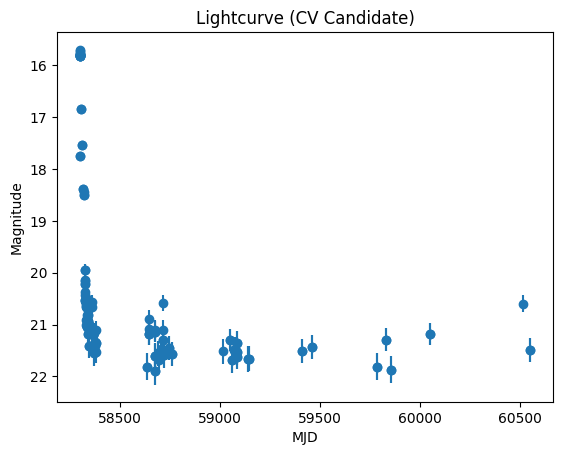

In [13]:
# 5. PLOT CV LIGHTCURVE
plt.figure()
plt.errorbar(t_cv, mag_cv, yerr=err_cv, fmt='o')

plt.gca().invert_yaxis()  # important for magnitude
plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title("Lightcurve (CV Candidate)")
plt.savefig("cv_lc.png")
plt.show()

In [14]:
# Unknown
t_unk = np.array(unk_obj['mjd_r'])
mag_unk = np.array(unk_obj['mag_r'])
err_unk = np.array(unk_obj['magerr_r'])

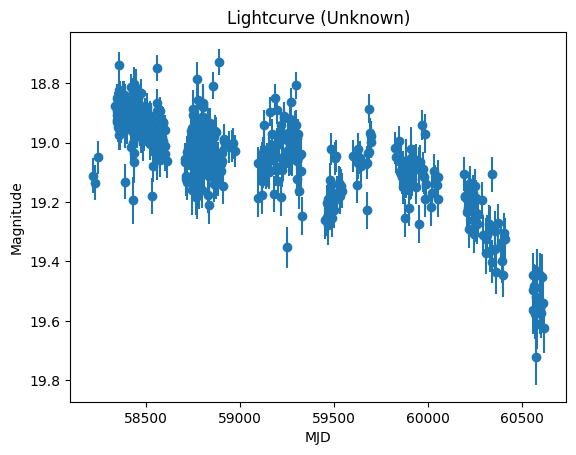

In [15]:
# 6. PLOT UNKNOWN LIGHTCURVE
plt.figure()
plt.errorbar(t_unk, mag_unk, yerr=err_unk, fmt='o')

plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title("Lightcurve (Unknown)")
plt.savefig("lc_un.png")
plt.show()

In [16]:
df_mcv=pd.read_csv("lightcurves_grouped_r_clean.csv")

In [17]:
df_mcv

,object,oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,...,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
0,V479 And,648209100001736;648209100001736;64820910000173...,51444796;51744365;51943052;52046682;52047856;5...,2458268.9448206285;2458271.9407102177;2458273....,58268.447963;58271.4436574;58273.4305208;58274...,17.0837059;16.9779816;17.2938271;17.006897;17....,0.0176795237;0.016920926;0.01945973;0.01712002...,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;32768;0;0;0;0;0;...,zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;z...,4.7371373;4.7372014;4.7372024;4.7371861;4.7371...,...,0x9;0x9;0x9;0x9;0x9;0x9;0x9;0x9;0x9;0x9;0x9;0x...,0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x...,19.7900009;20.3400002;20.5100002;20.6100006;20...,26.1137085;26.0858154;26.1201534;26.1772385;26...,0.038234517;0.0282069538;0.0276359823;0.026529...,0.0867828652;0.108281545;0.0973510891;0.095599...,1.4550611e-05;7.96109089e-06;7.63642038e-06;7....,30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;3...,1.78600001;1.73699999;1.83700001;1.43700004;1....,1;1;3;3;1;3;3;1;3;3;1;3;3;3;1;3;1;1;3;3;3;1;1;...
1,V1309 Ori,457201400006865;457201400006865;45720140000686...,58448195;59047807;59648598;59944752;60244373;6...,2458338.979216509;2458344.9758162564;2458350.9...,58338.481956;58344.4780787;58350.4859838;58353...,15.5439272;15.5913401;15.7149591;15.5899267;15...,0.0106142201;0.0107031371;0.0109596532;0.01070...,0;0;0;0;0;0;0;0;0;0;0;32768;0;0;0;0;0;32768;32...,zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;z...,78.92259149999998;78.9226245;78.9226273;78.922...,...,0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x1;0x...,0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x...,20.4099998;20.8099995;20.9500008;20.7999992;19...,25.7441196;25.7812386;25.7523899;25.8664207;25...,0.0305218752;0.0268952418;0.022681633;0.022724...,0.09522596;0.0910272375;0.0906809047;0.0882402...,7.69150483e-06;6.04451634e-06;4.11102656e-06;4...,30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;3...,2.3269999;2.06299996;1.71099997;2.19300008;2.0...,1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;3;1;1;3;1;...
2,AI Tri,652203400004823;652203400004823;65220340000482...,52848159;53446642;54048247;54342804;54642347;5...,2458282.9776469944;2458288.9628736307;2458294....,58282.4815972;58288.4664236;58294.4824769;5829...,15.6091309;16.0308838;16.0903511;15.8880234;15...,0.0125643201;0.0135526229;0.0137271676;0.01317...,32768;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...,zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;z...,30.95253;30.9525246;30.9525378;30.952526;30.95...,...,0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x...,0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x4;0x...,19.3099995;20.0100002;20.3199997;19.7900009;20...,25.5050449;26.0913143;26.1389523;26.0662403;26...,0.0409212299;0.0367659517;0.0281282198;0.03608...,0.127520263;0.102819696;0.0943818465;0.0967496...,2.36266897e-05;1.4708763e-05;8.72953933e-06;1....,30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;3...,2.00200009;1.98300004;1.57500005;2.24799991;2....,1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;3;3;1;3;3;3;1;...
3,J0649-0737,359215300024705;359215300024705;35921530002470...,46218099;46317870;46420027;46519597;61350256;6...,2458216.6808496336;2458217.6784727187;2458218....,58216.1809954;58217.1787037;58218.2002778;5821...,16.8057423;16.8111572;16.825985;16.5998039;16....,0.0159951728;0.0160298198;0.0161255933;0.01479...,0;32768;0;0;0;0;0;0;0;0;0;0;0;32768;0;0;0;0;0;...,zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;zr;z...,102.4621835;102.4621674;102.4622314;102.462196...,...,0xf;0xf;0xf;0xf;0xf;0xf;0xf;0xf;0xf;0xf;0xf;0x...,0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x3;0x...,19.8099995;18.2999992;19.3700008;19.5100002;20...,26.1435432;25.0099621;26.0516281;26.1060352;26...,0.0180626363;0.0716980547;0.0312066711;0.02548...,0.0875629112;0.0412542932;0.0755853206;0.07672...,4.94289634e-06;7.17791772e-05;1.36911904e-05;9...,30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;30.0;3...,1.88499999;1.88999999;2.26999998;2.23900008;2....,1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;.

In [18]:
# Function to convert string to array
def to_array(x):
    return np.array([float(i) for i in str(x).split(';') if i != ''])

# Apply conversion
df_mcv['mjd'] = df_mcv['mjd'].apply(to_array)
df_mcv['mag'] = df_mcv['mag'].apply(to_array)
df_mcv['magerr'] = df_mcv['magerr'].apply(to_array)

In [19]:
cv_obj = df_mcv.sample(n=1, random_state=42).iloc[0]
print("CV object:", cv_obj['object'])

CV object: DW Cnc


In [20]:
# CV
t_cv = cv_obj['mjd']
mag_cv = cv_obj['mag']
err_cv = cv_obj['magerr']


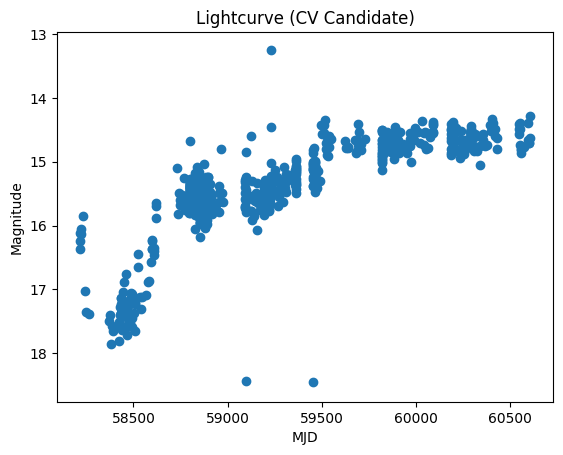

In [21]:
# 5. PLOT CV LIGHTCURVE
plt.figure()
plt.errorbar(t_cv, mag_cv, yerr=err_cv, fmt='o')

plt.gca().invert_yaxis()  # important for magnitude
plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title("Lightcurve (CV Candidate)")
plt.savefig("mcv_lc.png")
plt.show()